## Task 1.1 Summarize the GWAS results


In this first part of the assignement, we are going to load the summary results from a Genome-Wide Association Study (GWAS) and examine its results. In the second part, we examine the mouse homologous gene.

In [36]:
#Load packages 
# basic modules
import os
import sys
import numpy as np
import pandas as pd
import scipy.linalg as la
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
### THE TEXT AND CODE IN THIS FIELD IS PROVIDED TO THE STUDENTS
#
### Read ALL instructions FIRST before you begin your data analysis
#
# We are going to examine the GWAS ouput (i.e. summary statistics) of the 2018 GWAS of Major Depression conducted by the PGC.
# The data belong to this publication: Nat Genet. 2018 May;50(5):668-681. doi: 10.1038/s41588-018-0090-3. PMID:29700475
#
# Download this summary statistics file:
#! wget "https://www.dropbox.com/scl/fi/yj3m8d2puymhdzufanhs9/MDD2018_ex23andMe.txt?rlkey=4dl6gdi977dyj6neuwjtdf1xv&st=82vc8u0o&dl=0"  -O MDD_2018_original.tsv

# Download the README file:
#! wget "https://www.dropbox.com/scl/fi/0buvztu2sl6xa12vwvwyb/pgc-mdd-2018-readme.pdf?rlkey=r6qdropq18mi5rowplhoagcp8&st=v4i71xip&dl=0" -O MDD_2018_README.pdf

# Read the README file before moving to Task 1.1



--2025-12-02 15:56:59--  https://www.dropbox.com/scl/fi/yj3m8d2puymhdzufanhs9/MDD2018_ex23andMe.txt?rlkey=4dl6gdi977dyj6neuwjtdf1xv&st=82vc8u0o&dl=0
Herleiden van www.dropbox.com (www.dropbox.com)... 162.125.65.18
Verbinding maken met www.dropbox.com (www.dropbox.com)|162.125.65.18|:443... verbonden.
HTTP-verzoek is verzonden; wachten op antwoord... 302 Found
Locatie: https://ucc4c6e30caa210f9868f499f4d7.dl.dropboxusercontent.com/cd/0/inline/C2SIEUH_y6hFfPQ0AT8GtmEzjj5Dzc_dWUsWdyIFEmXbAACrTGBey5If_8T_YWdpL_Jz-NvAuc5B00i6Ck-ijueyrzPyL-16eAIFe6iFaJkcetxoP0zGiYI-esKaLUrI4CY/file# [volgen...]
--2025-12-02 15:57:00--  https://ucc4c6e30caa210f9868f499f4d7.dl.dropboxusercontent.com/cd/0/inline/C2SIEUH_y6hFfPQ0AT8GtmEzjj5Dzc_dWUsWdyIFEmXbAACrTGBey5If_8T_YWdpL_Jz-NvAuc5B00i6Ck-ijueyrzPyL-16eAIFe6iFaJkcetxoP0zGiYI-esKaLUrI4CY/file
Herleiden van ucc4c6e30caa210f9868f499f4d7.dl.dropboxusercontent.com (ucc4c6e30caa210f9868f499f4d7.dl.dropboxusercontent.com)... 162.125.65.15
Verbinding maken met ucc

**Q1.1.** Load the **tab** separated file 'MDD_2025_gwas_data.tsv' into a table and **check the content and the format**. Show your code and explain what you are doing and why. [2 points]

Relevant column headers:
 1 CHROM: Chromosome;
 2	POS: Base-pair position (GRCh37);
 3	SNP: SNP Marker ID (rs identifier);
 8	PVAL: P-value;


In [51]:
#Here I am loading the data by the read_csv function. As the data is seperated by tabs (tsv) I need to acccount for that. 
df = pd.read_csv('/Users/sietsehornstra/Desktop/GitHub/BigDataCourse/Exam/Assignment2/MDD_2018_original.tsv', sep='\t')

#To show a part of the table to see if it is correctly imported
df.head 

#To check the the amount of rows and columns and their datatype 
df.info()


/var/folders/hf/4zfg83ws2236bbgknptwvd200000gn/T/ipykernel_43411/39311079.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/sietsehornstra/Desktop/GitHub/BigDataCourse/Exam/Assignment2/MDD_2018_original.tsv', sep='\t')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13554550 entries, 0 to 13554549
Data columns (total 19 columns):
 #   Column        Dtype  
---  ------        -----  
 0   CHR           object 
 1   SNP           object 
 2   BP            float64
 3   A1            object 
 4   A2            object 
 5   FRQ_A_59851   float64
 6   FRQ_U_113154  float64
 7   INFO          float64
 8   OR            float64
 9   SE            float64
 10  P             float64
 11  ngt           object 
 12  Direction     object 
 13  HetISqt       float64
 14  HetDf         float64
 15  HetPVa        float64
 16  Nca           float64
 17  Nco           float64
 18  Neff          float64
dtypes: float64(13), object(6)
memory usage: 1.9+ GB



**Q1.2.** How many SNPs were tested?  [1 point]



In [3]:
countsnp = df['SNP'].nunique()

print(countsnp)

13554489



**Q1.3.** Find the **most significant SNP**. What is this top SNP's rs identifier? [1 point]


In [4]:
Smallp = df['P'].idxmin()

namesmallSNP = df.loc[Smallp, ['SNP', 'P']]
print(namesmallSNP)
 

SNP    rs76025409
P             0.0
Name: 6510839, dtype: object



**Q1.4.** Using the NCBI online database, in which gene is SNP rs9479138 located? [0.5 point]





The SNP rs9479138 is located near the ESR1 gene on chromosome 6. 


https://www.ncbi.nlm.nih.gov/gene/?term=rs9479138

A/C/T single-nucleotide variation in the ESR1 gene on chromosome 6



**Q1.5.** Looking further in the NCBI database, in which body tissue or organ is this gene most expressed? Provide a link/url showing how you got to this answer. [0.5 point]



The gene is most expressed in the adrenal at 10 weeks. 


https://www.ncbi.nlm.nih.gov/gene/2099





## Task 1.2 Microarray database
Another gene that has often been associated with Major Depression is **PGBD1**.In the Allen Institute microarray database, search for expression patterns of PGBD1: https://human.brain-map.org/microarray/search.

Download the relevant data for PGB1 (first probe, first row). There are two ways to do this:
1. Select the top row (probe) and download this data. Upload the data into  Colab by clicking on the 'file' icon on the top left corner.
2. Run the code provided below using wget commands (pointing to a dropbox database).

In [5]:
#### This is provided to the students! #######
#downloading data
#! wget 'https://www.dropbox.com/scl/fi/th8ykvjnk9rlao0ccp47d/Columns.csv?rlkey=dttm23lamkhugkypb0r5bgaj2&st=1wkbgc7r&dl=0' -O Columns.csv
#! wget 'https://www.dropbox.com/scl/fi/xs9g0r3egrxi93hhn9pel/Expression.csv?rlkey=jf47vz3ez0mxeascgjdqjn6rc&st=92e3dfew&dl=0' -O Expression.csv
#! wget 'https://www.dropbox.com/scl/fi/j2cn98z1vu5igppx69ayf/Contents.txt?rlkey=ew526p39wpe78os3x46rzglrg&st=wd6jzr40&dl=0' -O Contents.txt

--2025-12-02 11:35:44--  https://www.dropbox.com/scl/fi/th8ykvjnk9rlao0ccp47d/Columns.csv?rlkey=dttm23lamkhugkypb0r5bgaj2&st=1wkbgc7r&dl=0
Herleiden van www.dropbox.com (www.dropbox.com)... 162.125.65.18
Verbinding maken met www.dropbox.com (www.dropbox.com)|162.125.65.18|:443... verbonden.
HTTP-verzoek is verzonden; wachten op antwoord... 302 Found
Locatie: https://ucf98f572b76060f287e8466ec8f.dl.dropboxusercontent.com/cd/0/inline/C2SlJfhqG0TlqnTwSb1Q1ujeaZRD-tJfcT73dZ-s5Vih7GHTGc18MMVZMK9dGUH-KSCY0EdHNOXP7uPpIcTpxME_Cp7frz5v50YIIfh-EhVKqEZrjw6FWg1bQkDd3NQFGqo/file# [volgen...]
--2025-12-02 11:35:45--  https://ucf98f572b76060f287e8466ec8f.dl.dropboxusercontent.com/cd/0/inline/C2SlJfhqG0TlqnTwSb1Q1ujeaZRD-tJfcT73dZ-s5Vih7GHTGc18MMVZMK9dGUH-KSCY0EdHNOXP7uPpIcTpxME_Cp7frz5v50YIIfh-EhVKqEZrjw6FWg1bQkDd3NQFGqo/file
Herleiden van ucf98f572b76060f287e8466ec8f.dl.dropboxusercontent.com (ucf98f572b76060f287e8466ec8f.dl.dropboxusercontent.com)... 162.125.65.15
Verbinding maken met ucf98f572b760

**Read the "Contents.txt" file.**

**Load the Expression.csv file and the Columns.csv file in python.**


In [52]:
df_expression = pd.read_csv('/Users/sietsehornstra/Desktop/GitHub/BigDataCourse/Exam/Assignment2/Expression.csv', header = None )
df_columns = pd.read_csv('/Users/sietsehornstra/Desktop/GitHub/BigDataCourse/Exam/Assignment2/Columns.csv')




**Q1.6**  Format the data of Expression.csv and Columns.csv so that you have a table with 1 column of PGB1 expression values, next to columns with information of regions and subjects (donors). You should have 1 row per brain structure for each subject. (1 point)


In [53]:

df_columns['Expression'] = df_expression.T


**Q1.7** Calculate the mean expression accross participants per brain structure.  In which brain structure does this PGB1 have the highest mean expression? (0.5 point)


In [54]:


listmeanstructure = df_columns.groupby('structure_name')['Expression'].mean()

print(listmeanstructure.idxmax(), listmeanstructure.max())


anterior orbital gyrus 259381.114975



**Q1.8**   How many missing values are there for the expression of this gene across all brain regions? And for the brain region with the highest expression? (0.5 point)


In [48]:
print(df_columns['Expression'].isna().sum())

df_columns[df_columns['structure_name'] == 'anterior orbital gyrus']['Expression'].isna().sum()

173


np.int64(2)


**Q1.9**  Does PGBD1 look consistently highly expressed across subjects in this top brain region? For full points, consider patterns of PGBD1 expression across different subjects and brain regions. Use figures and/or statistics to help you decide. (2 points)


In [55]:

df_top = df_columns[df_columns["structure_name"] == "anterior orbital gyrus"]

df_top["Expression"].describe()


count    4.000000e+00
mean     2.593811e+05
std      5.187619e+05
min     -2.452000e-01
25%     -5.402500e-02
50%      3.525500e-01
75%      2.593815e+05
max      1.037524e+06
Name: Expression, dtype: float64

As seen in the results above the std is almost twice as much as the mean which shows a large spread. This suggests that the increased average is driven by a single participant and that expression levels are very inconsistent between IDs.

<function matplotlib.pyplot.show(close=None, block=None)>

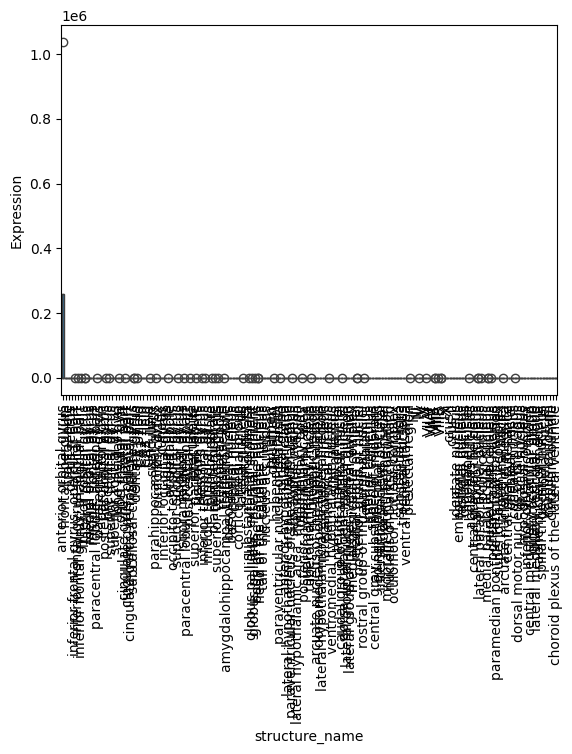

In [56]:
sns.boxplot(data=df_columns, x="structure_name", y="Expression")
plt.xticks(rotation=90)
plt.show


Only the anterior orbital gyrus stands out as an anomaly when examining the boxplot with all structure names. PGBD1 is low and rather consistent everywhere else in the brain, as seen by the expression values near zero in all other regions.


**Q1.10**   Looking at a coarser level of analysis, in which (larger) brain structures is PGBD1 most highly expressed? (1 point)

In [20]:
listmeantoplevel = df_columns.groupby('top_level_structure_name')['Expression'].mean()

print(listmeantoplevel.idxmax(), listmeantoplevel.max())

print(listmeantoplevel.sort_values(ascending=False))


frontal lobe 11401.91179010989
top_level_structure_name
frontal lobe             11401.911790
cerebellar cortex            0.974824
insula                       0.633558
cingulate gyrus              0.594238
ventral thalamus             0.569667
temporal lobe                0.534298
parietal lobe                0.520891
occipital lobe               0.465873
claustrum                    0.388467
hippocampal formation        0.306514
parahippocampal gyrus        0.284817
subthalamus                  0.200617
globus pallidus              0.083318
dorsal thalamus             -0.173665
brain                       -0.286933
white matter                -0.441575
pontine tegmentum           -0.443937
myelencephalon              -0.516247
striatum                    -0.574047
basal forebrain             -0.577191
mesencephalon               -0.661383
amygdala                    -0.706656
basal part of pons          -0.774350
hypothalamus                -0.833715
cerebellar nuclei           -0.9





--------------------------

# Task 2: Mouse phenome database

For this task, you will download and import some files from the Mouse Phenome Database (MPD, https://phenome.jax.org). This is a database containing a large amount of mouse experimental data, where information on several phenotypes/genotypes can be found.

Execute the wget commands to download the following files to the colab session and the pd.read_csv commands to load them into python.

Here is a short description of the file contents.

- measurements.csv (= Description, units, and other metadata attributes for all phenotype measures (traits) in MPD. One row per measure.)
- straininfo.csv (= Strain name, vendor, stock number, web page URL, MPD strain ID, and other attributes for each mouse strain in MPD. One row per strain.)
- strainmeans.csv.gz (= Strain averages, SD, SEM, N, CV for all numeric strain survey phenotype measures in MPD.)
- animaldatapoints.csv.gz (= Individual mouse readings for all strain survey phenotype measures. One row per animal reading.)


In [48]:
measurements = pd.read_csv('/Users/sietsehornstra/Desktop/GitHub/BigDataCourse/Exam/Assignment2/measurements.csv')
straininfo = pd.read_csv('/Users/sietsehornstra/Desktop/GitHub/BigDataCourse/Exam/Assignment2/straininfo.csv')
strainmeans = pd.read_csv('/Users/sietsehornstra/Desktop/GitHub/BigDataCourse/Exam/Assignment2/strainmeans.csv.gz')
animaldatapoints = pd.read_csv('/Users/sietsehornstra/Desktop/GitHub/BigDataCourse/Exam/Assignment2/animaldatapoints.csv.gz')

**Q2.1** How many different mouse strains are listed in the database? (1pt)


In [22]:
print(straininfo['strainname'].nunique())

4705



**Q2.2** Several strains are not included in projects (n_proj is `nan`). How many strains were actually used in projects? (1pt)


In [23]:

straininfo['n_proj'].notna().sum()


np.int64(4366)


**Q2.3** Which strain was used in the most projects, give the name and id (1 pt)


In [24]:
print(straininfo.loc[straininfo['n_proj'].idxmax(), ['strainname', 'n_proj', 'mpd_strainid']])


strainname      C57BL/6J
n_proj             326.0
mpd_strainid           7
Name: 6, dtype: object



**Q2.4** Using the measurements and strainmeans file, look up the experiment with measnum = 29508. Give the description of the experiment and the average results for strain C3HeB/FeJ. (**hint:** You should get two values, one for males and one for females) (1 pts)


In [30]:
print(measurements.loc[measurements['measnum'] == 29508, 'descrip'])

strainfilter = strainmeans[strainmeans['measnum'] == 29508]
strainfilter = strainfilter[strainfilter['strain'] == 'C3HeB/FeJ']

print(strainfilter[['strain', 'sex', 'mean']])

2478    cardiac ejection fraction, 
Name: descrip, dtype: object
          strain sex  mean
63143  C3HeB/FeJ   f  63.7
63147  C3HeB/FeJ   m  59.9



**Q2.5** For the experiment above (29508) take the results from BALB/cByJ mice (strainid = 50) in animaldatapoints and perform a two-tailed two-sample t-test for `males > females`. What are the t-value and the p-value? (2 pts)


In [37]:

df = animaldatapoints[animaldatapoints['measnum'] == 29508]
df = d[d['strainid'] == 50]

m = df[df['sex'] == 'm']['measval']
f = df[df['sex'] == 'f']['measval']

from scipy.stats import ttest_ind

t, p = ttest_ind(m, f)

print(t, p)

-0.1563527684611572 0.8788663947761268



**Q2.6** Plot a dotplot of the the body weight (measnum = 11201 listed in `measurements`) on the y-axis as a function of strain name on the x axis. Color-code sex. Add sensible title and axis labels. Make the axis legend lisible. (**hint:** strain ID is encoded differently in the tables!!!) (2 pts)


In [49]:
bw = animaldatapoints[animaldatapoints['measnum'] == 11201]

11201 is not in the dataset animaldatapoints. 

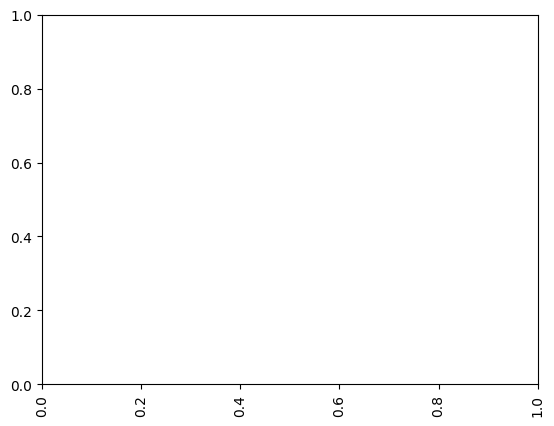

In [46]:
bw = animaldatapoints[animaldatapoints['measnum'] == 11201]
bw = bw.merge(straininfo[['mpd_strainid','strainname']], left_on='strainid', right_on='mpd_strainid')

sns.stripplot(data=bw, x='strainname', y='measval')
plt.xticks(rotation=90)
plt.show()


In [44]:
bw = animaldatapoints[animaldatapoints['measnum'] == 11201]

print(measurements.loc[measurements['measnum'] == 11201, 'descrip'])

575    body weight, 
Name: descrip, dtype: object


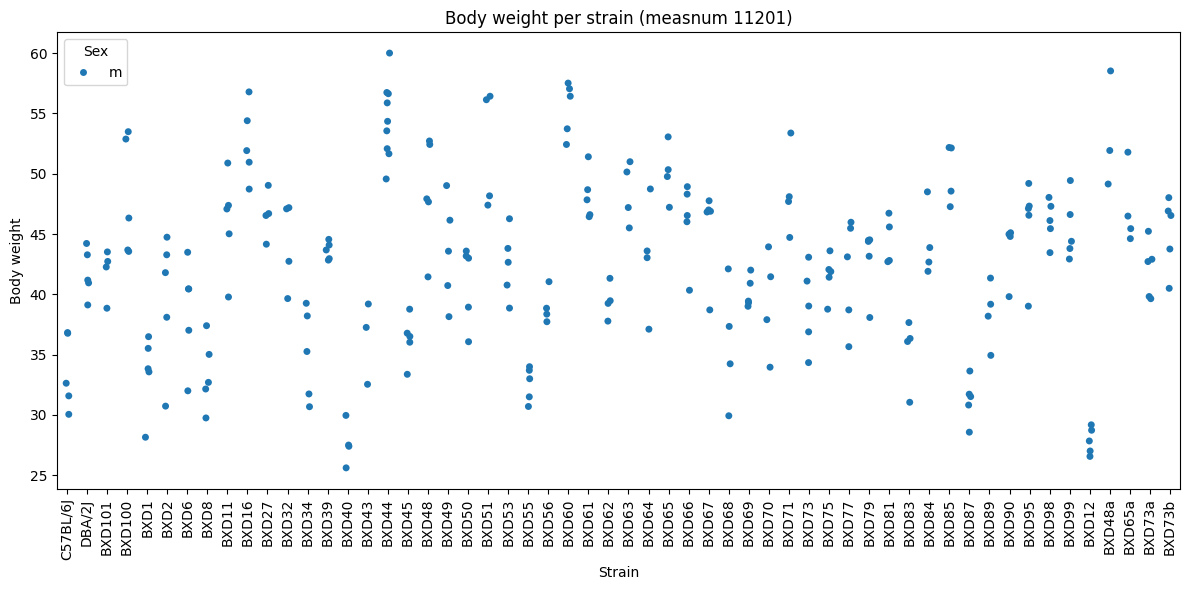

In [45]:
bw = animaldatapoints[animaldatapoints['measnum'] == 111201]

bw = bw.merge(straininfo[['mpd_strainid','strainname']],
              left_on='strainid',
              right_on='mpd_strainid',
              how='left')

plt.figure(figsize=(12,6))
sns.stripplot(data=bw, x='strainname', y='measval', hue='sex', dodge=True)

plt.title("Body weight per strain (measnum 11201)")
plt.xlabel("Strain")
plt.ylabel("Body weight")
plt.xticks(rotation=90)
plt.legend(title="Sex")
plt.tight_layout()
plt.show()


**Q2.7** The project  "Wahlsten1" (projsym = "Wahlsten1" listed in `measurements`) examines anxiety behaviour using two assays (open field test) and elevated plus maze (epm) in 20 strains, and across both sexes. Plot the mean values across strain and sex for measnum =  10831 (percentage of time spent 10 cm from the wall, higher values indicate more anxiety) on the x-axis, and measnum = 10852 (percentage of time spent in open arms vs closed. lower values indicate less anxiety) on the y-axis. Add a regression line to the plot. Add sensible title and axis labels. Make the axis legend lisible. Get a correlation value for the two measurments. (3 pts)


In [1]:
# code to download the data

#! wget --no-check-certificate https://phenomedoc.jax.org/MPD_downloads/measurements.csv
#! wget --no-check-certificate https://phenomedoc.jax.org/MPD_downloads/straininfo.csv
#! wget --no-check-certificate https://phenomedoc.jax.org/MPD_downloads/strainmeans.csv.gz
#! wget --no-check-certificate https://phenomedoc.jax.org/MPD_downloads/animaldatapoints.csv.gz

--2025-12-01 23:43:34--  https://phenomedoc.jax.org/MPD_downloads/measurements.csv
Herleiden van phenomedoc.jax.org (phenomedoc.jax.org)... 34.49.178.191
Verbinding maken met phenomedoc.jax.org (phenomedoc.jax.org)|34.49.178.191|:443... verbonden.
HTTP-verzoek is verzonden; wachten op antwoord... 200 OK
Lengte: 1541446 (1,5M) [text/csv]
Wordt opgeslagen als: ‘measurements.csv’

measurements.csv    100%[===================>]   1,47M  --.-KB/s    in 0,1s    

2025-12-01 23:43:35 (9,94 MB/s) - '‘measurements.csv’' opgeslagen [1541446/1541446]

--2025-12-01 23:43:35--  https://phenomedoc.jax.org/MPD_downloads/straininfo.csv
Herleiden van phenomedoc.jax.org (phenomedoc.jax.org)... 34.49.178.191
Verbinding maken met phenomedoc.jax.org (phenomedoc.jax.org)|34.49.178.191|:443... verbonden.
HTTP-verzoek is verzonden; wachten op antwoord... 200 OK
Lengte: 361068 (353K) [text/csv]
Wordt opgeslagen als: ‘straininfo.csv’

straininfo.csv      100%[===================>] 352,61K  --.-KB/s    in 0,05s 

In [49]:
# code to load the data into pandas dataframes
import pandas as pd
measurements = pd.read_csv('/Users/sietsehornstra/Desktop/GitHub/BigDataCourse/Exam/Assignment2/measurements.csv') 
straininfo = pd.read_csv('/Users/sietsehornstra/Desktop/GitHub/BigDataCourse/Exam/Assignment2/straininfo.csv')
strainmeans = pd.read_csv('/Users/sietsehornstra/Desktop/GitHub/BigDataCourse/Exam/Assignment2/strainmeans.csv.gz')
animaldatapoints = pd.read_csv('/Users/sietsehornstra/Desktop/GitHub/BigDataCourse/Exam/Assignment2/animaldatapoints.csv.gz')